# 01-08 - Reading a Map You Drew

Our layered map from 01-02 is mostly empty, the buildings are a grey smear, and the axes are missing. None of that is a bug, and all of it is worth naming, because a map you cannot read honestly is a map you will misuse.

In this notebook we take that first plot apart, improve it one argument at a time, and practise saying out loud what each thing on the page is and what it is not.

Thirty minutes.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

# this notebook draws 7893 buildings several times over, so keep the stored
# pictures light rather than shipping a megabyte of pixels to every student
plt.rcParams["figure.dpi"] = 72

In [2]:
boundary = gpd.read_file("data/princeton_boundary.geojson").to_crs("EPSG:26918")
buildings = gpd.read_file("data/princeton_buildings.geojson").to_crs("EPSG:26918")
food = gpd.read_file("data/princeton_food.geojson").to_crs("EPSG:26918")

## The honest starting point

Here is the plot with no arguments at all, which is what you get if you ask for a picture and think no further:

<Axes: >

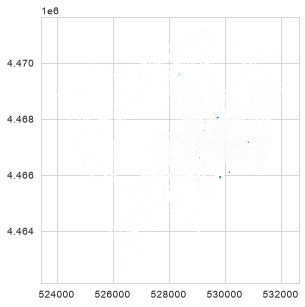

In [3]:
buildings.plot()

Small, grey, cramped, and with numbers along the edges in the hundreds of thousands, which are metres from the origin of the UTM zone and mean nothing to a reader.

It is not a bad plot. It is an unconsidered one, and every improvement below is one decision.

## Five decisions

Rather than a finished map appearing by magic, here is each change with what it costs and buys:

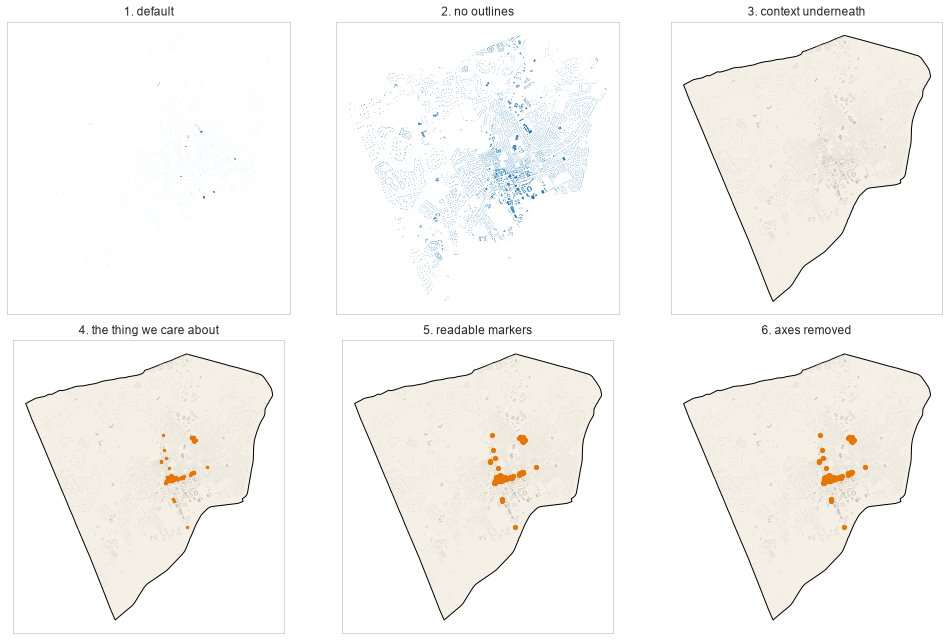

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
panels = axes.ravel()

buildings.plot(ax=panels[0])
panels[0].set_title("1. default")

buildings.plot(ax=panels[1], linewidth=0)
panels[1].set_title("2. no outlines")

boundary.plot(ax=panels[2], color="#f5f0e6", edgecolor="black")
buildings.plot(ax=panels[2], color="#c8c2b8", linewidth=0)
panels[2].set_title("3. context underneath")

boundary.plot(ax=panels[3], color="#f5f0e6", edgecolor="black")
buildings.plot(ax=panels[3], color="#c8c2b8", linewidth=0)
food.plot(ax=panels[3], color="#e77500", markersize=6)
panels[3].set_title("4. the thing we care about")

boundary.plot(ax=panels[4], color="#f5f0e6", edgecolor="black")
buildings.plot(ax=panels[4], color="#c8c2b8", linewidth=0)
food.plot(ax=panels[4], color="#e77500", markersize=18)
panels[4].set_title("5. readable markers")

boundary.plot(ax=panels[5], color="#f5f0e6", edgecolor="black")
buildings.plot(ax=panels[5], color="#c8c2b8", linewidth=0)
food.plot(ax=panels[5], color="#e77500", markersize=18)
panels[5].set_axis_off()
panels[5].set_title("6. axes removed")

for panel in panels[:5]:
    panel.set_xticks([])
    panel.set_yticks([])
plt.tight_layout()

Read the sequence rather than only the last panel.

**Panel two** removed the outlines. At this scale each building is about a pixel, so its outline was a large fraction of its own area and everything looked darker and fatter than it is.

**Panel three** put the municipal boundary underneath, which is what turns a cloud of shapes into a place.

**Panel four** added the food, and it is nearly invisible, because a marker size chosen for a close-up disappears in a town-wide view.

**Panel five** fixed that, and now the map says what it is about.

**Panel six** removed the axes, and this is the one to think hardest about. It looks the most finished and it is the least checkable: nothing on that panel now tells you where on Earth this is, how big it is, or what the units were. Removing the axes is right for a poster and wrong while you are still working, and the mistake is doing it out of habit rather than on purpose.

## Naming the artefacts

Three things about that map look like problems and are not. Being able to say why is the actual skill.

In [5]:
minx, miny, maxx, maxy = boundary.total_bounds
fminx, fminy, fmaxx, fmaxy = food.total_bounds

print(f"the municipality spans   {(maxx - minx) / 1000:.1f} by {(maxy - miny) / 1000:.1f} km")
print(f"the food spans           {(fmaxx - fminx) / 1000:.1f} by {(fmaxy - fminy) / 1000:.1f} km")
print(f"all buildings cover      {buildings.geometry.area.sum() / 1e6:.2f} of {boundary.geometry.area.iloc[0] / 1e6:.2f} km2")
print(f"that is                  {buildings.geometry.area.sum() / boundary.geometry.area.iloc[0] * 100:.1f} percent of the town")

the municipality spans   8.9 by 9.6 km
the food spans           1.7 by 3.3 km
all buildings cover      2.36 of 47.66 km2
that is                  4.9 percent of the town


**The map is mostly empty.** The places to eat occupy a box 1.7 by 3.3 kilometres inside a municipality 8.9 by 9.6 kilometres across. The emptiness is the shape of the town, not a gap in the data, and if you cropped to the interesting part you would be making a different and more honest map.

**The buildings look like a smear.** They cover 2.36 of 47.66 square kilometres, i.e. under five percent of the area you are looking at, drawn at a scale where each is smaller than a pixel. Zooming in separates them.

**Data extent is not administrative extent.** This is the general form of the first point and it will catch you with any dataset: the box your data occupies and the boundary of the thing it describes are different, and confusing them leads to statements like "there are no restaurants in the north of Princeton" when what you mean is "nobody has mapped any".

Naming an artefact out loud is what stops a reader over-reading it. A caption saying "food places cluster along Nassau Street; the rest of the municipality is residential" costs one sentence and prevents a wrong conclusion.

## The aspect ratio

One more decision that is usually made for you and is occasionally wrong:

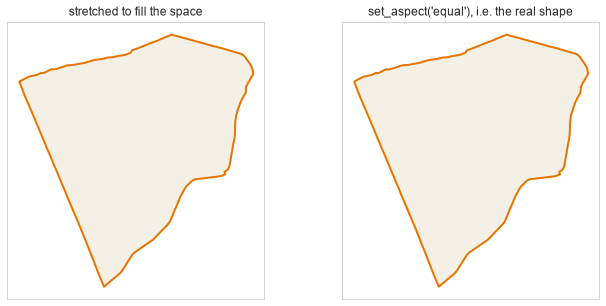

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

boundary.plot(ax=axes[0], color="#f5f0e6", edgecolor="#e77500", linewidth=2)
axes[0].set_title("stretched to fill the space")

boundary.plot(ax=axes[1], color="#f5f0e6", edgecolor="#e77500", linewidth=2)
axes[1].set_aspect("equal")
axes[1].set_title("set_aspect('equal'), i.e. the real shape")

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])

The left panel has been stretched to fill its box, so the town is the wrong shape. The right one is correct.

Note that geopandas usually gets this right on its own, and the panels above look similar because our figure happened to be nearly square. It goes wrong when you set an unusual `figsize`, or when you draw into a subplot grid, which is exactly when you are least likely to notice. `set_aspect("equal")` costs one line and removes the doubt.

## Backgrounds, and a cautionary tale

You can put a real basemap under your data with `contextily`, which fetches map tiles from the internet:

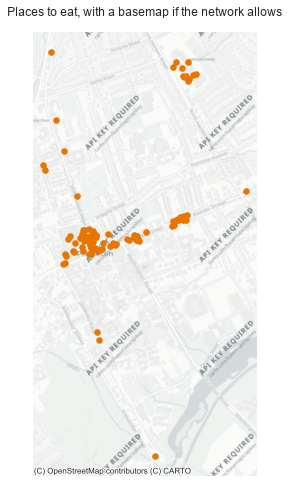

In [7]:
import contextily as cx

ax = food.plot(figsize=(8, 8), color="#e77500", markersize=30)
ax.set_axis_off()
ax.set_title("Places to eat, with a basemap if the network allows")

try:
    cx.add_basemap(ax, crs=food.crs, source=cx.providers.CartoDB.Positron)
except Exception as problem:
    print(f"no basemap this time: {type(problem).__name__}")
    print("the analysis underneath is unaffected")

Whether you got a background depends on your network, and the notebook carries on either way, which is why that call is wrapped.

Note the `crs=food.crs` argument. The tiles are drawn in Web Mercator, and `contextily` needs to know what your data is in so that it can line them up. Get that wrong and your points land in the ocean, which is a satisfying kind of error because it is at least obvious.

Now the cautionary tale, and it happened while this precept was being prepared. An AI agent was asked to make a map of Princeton and tried three different tile providers in a row. The first returned images reading "API KEY REQUIRED". The second returned images reading "Access blocked". Both were served with an HTTP 200, i.e. a success code, and both were perfectly valid PNG files. No exception was raised, and no amount of error handling would have caught either.

Its own conclusion is the best sentence anybody produced during the preparation of this course: every failure returned a valid image, so only rendering the output and looking at it caught them.

**A basemap is a picture fetched from somebody else's server. It is not your data, it can fail silently, and it can be wrong.** Look at your maps.

## Check your understanding

1. A legend lists railways but you see none on the map. Name two explanations and say how you would tell them apart.
2. Why does turning the axes off make a map look more finished and less checkable?
3. Your basemap tiles say "API KEY REQUIRED". What did your code do wrong, and what did your code report?
4. Data extent and administrative extent differ for our food layer. Give a sentence a reader might wrongly conclude if nobody points that out.

## Where we are

You can take an unconsidered plot apart, improve it deliberately, name the three artefacts that are not bugs, and treat a background image as the untrusted thing it is.

In 01-09, the last notebook in this folder, we ask our walk-radius question nine times and find something about Princeton that none of us expected.

## Further resources

Nothing in this course requires anything below.

The matplotlib guide to figures and axes explains the objects underneath every plot in this course: https://matplotlib.org/stable/users/explain/figure/figure_intro.html. The geopandas mapping gallery is the fastest way to see what is possible and to steal an idea: https://geopandas.org/en/stable/gallery/index.html. Contextily documents its providers and their terms at https://contextily.readthedocs.io.

The data is an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright.